<a href="https://colab.research.google.com/github/karthik-srivathsa-05/flyrank-ai/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/karthik-srivathsa-05/flyrank-ai/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

### Research question

Can February 2026 content-performance signals be used to rank pages by their likelihood of experiencing a meaningful decline in March 2026?

### Decision supported

The output is intended to support a content-review queue. Pages with higher predicted decline probability can be reviewed earlier by an SEO or content team.

The model is a decision-support tool, not a causal model. A high score indicates that the observed February signals are associated with a higher likelihood of the defined March decline in this dataset. It does not prove that refreshing a page will improve its future performance.

### Prediction target

A page is labelled `1` when its March clicks fall by more than 30% relative to its February click baseline:

`March clicks < 0.70 × February clicks`

Otherwise, the page is labelled `0`.

Only pages with positive February clicks are included in the modelling population because a percentage decline is not meaningful when the February baseline is zero.

## 2. Data

The analysis uses the FlyRank internship warehouse release available through the Hugging Face dataset environment.

The modelling window is February 2026. February data is used to construct the feature vector available at the end-of-February decision point.

March 2026 is used only to construct the future outcome label and is never used as a model feature.

### Data windows

- February 2026: 2026-02-01 to 2026-02-28
- March 2026: 2026-03-01 to 2026-03-31

The February performance table contains 7,355,108 daily observations and the March performance table contains 9,841,378 daily observations.

The modelling population is restricted to client-content observations with positive February clicks, because the decline label is defined relative to February clicks.

Client and content identifiers are retained only for grouping and reporting. They are not used as model features.

No client names, URLs, search queries, or other private identifiers are included in the analysis output.

In [33]:
import os
import getpass
import duckdb
import pandas as pd
import numpy as np

from IPython.display import display

print("Core libraries loaded.")

Core libraries loaded.


In [34]:
def get_hf_token():
    token = os.environ.get("HF_TOKEN")

    if token:
        return token

    try:
        from google.colab import userdata
        token = userdata.get("HF_TOKEN")

        if token:
            return token
    except Exception:
        pass

    return getpass.getpass("Enter Hugging Face READ token: ")


HF_TOKEN = get_hf_token()

if not HF_TOKEN:
    raise ValueError("HF_TOKEN was not provided.")

con = duckdb.connect()

con.execute("SET enable_progress_bar = false")

try:
    con.execute("INSTALL httpfs")
except Exception:
    pass

con.execute("LOAD httpfs")

con.execute(
    "CREATE OR REPLACE SECRET hf "
    f"(TYPE HUGGINGFACE, TOKEN '{HF_TOKEN}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"

FACT_FEB = (
    f"read_parquet("
    f"'{REL}/fact_content_daily_performance/month=2026-02/*.parquet'"
    f")"
)

FACT_MAR = (
    f"read_parquet("
    f"'{REL}/fact_content_daily_performance/month=2026-03/*.parquet'"
    f")"
)

print("DuckDB version:", con.sql("SELECT version()").fetchone()[0])
print("httpfs loaded successfully.")
print("Hugging Face authentication configured.")

DuckDB version: v1.3.2
httpfs loaded successfully.
Hugging Face authentication configured.


In [35]:
feb_check = con.sql(f"""
SELECT
    COUNT(*) AS row_count,
    MIN(report_date) AS min_report_date,
    MAX(report_date) AS max_report_date
FROM {FACT_FEB}
""").df()

mar_check = con.sql(f"""
SELECT
    COUNT(*) AS row_count,
    MIN(report_date) AS min_report_date,
    MAX(report_date) AS max_report_date
FROM {FACT_MAR}
""").df()

print("February:")
display(feb_check)

print("\nMarch:")
display(mar_check)

February:


,row_count,min_report_date,max_report_date
0,7355108,2026-02-01,2026-02-28



March:


,row_count,min_report_date,max_report_date
0,9841378,2026-03-01,2026-03-31


In [36]:
model_frame = con.sql(f"""
WITH feb AS (
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(COALESCE(gsc_impressions, 0)) AS impressions_30d,
        SUM(COALESCE(gsc_clicks, 0)) AS clicks_30d,

        AVG(
            CASE
                WHEN gsc_avg_position IS NOT NULL
                THEN gsc_avg_position
            END
        ) AS avg_position,

        COUNT(
            CASE
                WHEN COALESCE(gsc_impressions, 0) > 0
                THEN 1
            END
        ) AS days_with_impressions

    FROM {FACT_FEB}

    WHERE report_date BETWEEN DATE '2026-02-01'
                          AND DATE '2026-02-28'

    GROUP BY
        client_hash_id,
        content_hash_id
),

march AS (
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(COALESCE(gsc_clicks, 0)) AS march_clicks

    FROM {FACT_MAR}

    WHERE report_date BETWEEN DATE '2026-03-01'
                          AND DATE '2026-03-31'

    GROUP BY
        client_hash_id,
        content_hash_id
),

feb_baseline AS (
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(COALESCE(gsc_clicks, 0)) AS feb_clicks

    FROM {FACT_FEB}

    WHERE report_date BETWEEN DATE '2026-02-01'
                          AND DATE '2026-02-28'

    GROUP BY
        client_hash_id,
        content_hash_id
)

SELECT
    f.client_hash_id,
    f.content_hash_id,

    f.impressions_30d,
    f.clicks_30d,
    f.avg_position,
    f.days_with_impressions,

    COALESCE(m.march_clicks, 0) AS march_clicks,
    COALESCE(b.feb_clicks, 0) AS feb_clicks,

    CASE
        WHEN COALESCE(b.feb_clicks, 0) > 0
             AND COALESCE(m.march_clicks, 0)
                 < 0.70 * b.feb_clicks
        THEN 1
        ELSE 0
    END AS decline_label

FROM feb f

LEFT JOIN march m
    ON f.client_hash_id = m.client_hash_id
   AND f.content_hash_id = m.content_hash_id

LEFT JOIN feb_baseline b
    ON f.client_hash_id = b.client_hash_id
   AND f.content_hash_id = b.content_hash_id

WHERE COALESCE(b.feb_clicks, 0) > 0
""").df()

print("Modelling rows:", f"{len(model_frame):,}")
print("Columns:", list(model_frame.columns))

display(model_frame.head())

Modelling rows: 55,090
Columns: ['client_hash_id', 'content_hash_id', 'impressions_30d', 'clicks_30d', 'avg_position', 'days_with_impressions', 'march_clicks', 'feb_clicks', 'decline_label']


,client_hash_id,content_hash_id,impressions_30d,clicks_30d,avg_position,days_with_impressions,march_clicks,feb_clicks,decline_label
0,client_e547b89c05043229,content_9abd8b303f805847,733.0,6.0,6.495085,28,4.0,6.0,1
1,client_e547b89c05043229,content_6fe390ba3af1e456,2931.0,3.0,38.436254,28,5.0,3.0,0
2,client_e547b89c05043229,content_3ad5d2160242b9ca,970.0,2.0,9.710810,28,1.0,2.0,1
3,client_e547b89c05043229,content_a2bd730a7cf68316,551.0,1.0,6.017373,28,1.0,1.0,0
4,client_e547b89c05043229,content_babd931911c9ee33,2680.0,31.0,5.046562,28,15.0,31.0,1


In [37]:
label_summary = (
    model_frame["decline_label"]
    .value_counts()
    .rename_axis("decline_label")
    .reset_index(name="row_count")
)

label_summary["percentage"] = (
    100 * label_summary["row_count"] / len(model_frame)
)

display(
    label_summary.style.format({
        "percentage": "{:.2f}%"
    })
)

base_rate = model_frame["decline_label"].mean()

print(f"Decline base rate: {base_rate:.4f}")
print(f"Decline percentage: {base_rate * 100:.2f}%")

,decline_label,row_count,percentage
0,0,33376,60.58%
1,1,21714,39.42%


Decline base rate: 0.3942
Decline percentage: 39.42%


## 3. Methodology

The modelling decision point is the end of February 2026.

### Features

The model uses four February-only features:

1. `impressions_30d` — total February Google Search impressions
2. `clicks_30d` — total February Google Search clicks
3. `avg_position` — average observed Google Search position during February
4. `days_with_impressions` — number of February days with positive impressions

Client and content identifiers are excluded from the feature matrix.

### Label

A page is labelled `1` when:

`March clicks < 0.70 × February clicks`

This represents a decline of more than 30% from the February click baseline.

Pages with zero February clicks are excluded because a percentage decline cannot be defined from a zero baseline.

### Model

I use Logistic Regression because this is a binary classification problem and the output needs to be interpretable for a content-review queue.

Missing feature values are median-imputed using the training data and numeric features are standardized before fitting the classifier.

### Baseline

The Week-4 baseline is a transparent weighted ranking score based on three February signals:

- 50% lower-click signal
- 30% weaker-position signal
- 20% lower-coverage signal

Both the baseline and Logistic Regression are evaluated on exactly the same held-out test observations.

### Validation

The train/test split is grouped by `client_hash_id`. All observations belonging to the same client stay in either training or test.

This prevents pages from the same client appearing in both sets and reduces the risk of client-specific patterns leaking across the split.

The split uses a fixed random seed of 42 and a 20% test size.

### Leakage check

March outcome fields and the target label are not included in the feature matrix.

The model therefore uses only information that would have been available at the February 28 decision point.

In [38]:
from sklearn.model_selection import GroupShuffleSplit

FEATURES = [
    "impressions_30d",
    "clicks_30d",
    "avg_position",
    "days_with_impressions"
]

TARGET = "decline_label"
GROUP = "client_hash_id"

X = model_frame[FEATURES].copy()
y = model_frame[TARGET].copy()
groups = model_frame[GROUP].copy()

RANDOM_STATE = 42
TEST_SIZE = 0.20

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

print("Training rows:", f"{len(X_train):,}")
print("Test rows:", f"{len(X_test):,}")

print("\nTraining clients:", groups_train.nunique())
print("Test clients:", groups_test.nunique())

overlap = set(groups_train.unique()).intersection(
    set(groups_test.unique())
)

print("\nClient overlap:", len(overlap))

assert len(overlap) == 0

print("Grouped split check: PASSED")

Training rows: 34,860
Test rows: 20,230

Training clients: 32
Test clients: 9

Client overlap: 0
Grouped split check: PASSED


In [39]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        )
    )
])

model.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [40]:
model_probability = model.predict_proba(X_test)[:, 1]

model_prediction = (
    model_probability >= 0.50
).astype(int)

print("Predictions generated.")
print("Prediction count:", len(model_prediction))
print("Positive predictions:", model_prediction.sum())

Predictions generated.
Prediction count: 20230
Positive predictions: 1774


In [41]:
baseline_test = model_frame.iloc[test_idx].copy()

baseline_test["click_signal"] = (
    1 - baseline_test["clicks_30d"].rank(
        pct=True,
        method="average"
    )
)

baseline_test["position_signal"] = (
    baseline_test["avg_position"].rank(
        pct=True,
        method="average"
    )
)

baseline_test["coverage_signal"] = (
    1 - baseline_test["days_with_impressions"].rank(
        pct=True,
        method="average"
    )
)

baseline_test["baseline_score"] = (
    0.50 * baseline_test["click_signal"]
    + 0.30 * baseline_test["position_signal"]
    + 0.20 * baseline_test["coverage_signal"]
)

print("Baseline score created.")

display(
    baseline_test[
        [
            "client_hash_id",
            "content_hash_id",
            "clicks_30d",
            "avg_position",
            "days_with_impressions",
            "baseline_score",
            "decline_label"
        ]
    ]
    .sort_values(
        "baseline_score",
        ascending=False
    )
    .head(10)
)

Baseline score created.


,client_hash_id,content_hash_id,clicks_30d,avg_position,days_with_impressions,baseline_score,decline_label
40332,client_3197e6291363b4db,content_91e840b39a7ba247,1.0,47.000000,3,0.926120,1
12633,client_3197e6291363b4db,content_352d9fcaa95cc585,1.0,45.000000,2,0.925996,1
12641,client_3197e6291363b4db,content_bc20268efe2201b3,1.0,61.541667,5,0.924909,1
33679,client_9958f0a7ae1df715,content_718ab3123d9e76d5,1.0,58.200000,5,0.924790,1
24512,client_20259bd6705d81d4,content_f4aa2b83a36d872b,1.0,40.243651,4,0.924449,1
13843,client_ff644d8251367cbb,content_77e00d6e003b5f37,1.0,37.000000,3,0.924414,1
6226,client_9958f0a7ae1df715,content_6f3656a852e308ce,1.0,34.333333,3,0.923450,1
39268,client_73cda7b4e4f265ea,content_eb9b7ad63cea7fed,1.0,48.416667,6,0.922294,1
53972,client_20259bd6705d81d4,content_be85da0d3d2fe07f,1.0,49.519018,7,0.920875,1
12638,client_3197e6291363b4db,content_1ef322975cdd9cf3,1.0,47.211458,8,0.919990,1


In [42]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

y_test_array = y_test.to_numpy()

model_auc = roc_auc_score(
    y_test_array,
    model_probability
)

model_ap = average_precision_score(
    y_test_array,
    model_probability
)

baseline_probability = (
    baseline_test["baseline_score"].to_numpy()
)

baseline_auc = roc_auc_score(
    y_test_array,
    baseline_probability
)

baseline_ap = average_precision_score(
    y_test_array,
    baseline_probability
)

results = pd.DataFrame({
    "method": [
        "Week-4 baseline",
        "Logistic Regression"
    ],
    "ROC_AUC": [
        baseline_auc,
        model_auc
    ],
    "Average_Precision": [
        baseline_ap,
        model_ap
    ]
})

display(
    results.style.format({
        "ROC_AUC": "{:.4f}",
        "Average_Precision": "{:.4f}"
    })
)

print(f"Baseline ROC-AUC: {baseline_auc:.4f}")
print(f"Model ROC-AUC:    {model_auc:.4f}")
print(f"AUC difference:   {model_auc - baseline_auc:+.4f}")

print(f"\nBaseline Average Precision: {baseline_ap:.4f}")
print(f"Model Average Precision:    {model_ap:.4f}")
print(
    f"AP difference:              "
    f"{model_ap - baseline_ap:+.4f}"
)

,method,ROC_AUC,Average_Precision
0,Week-4 baseline,0.6194,0.4704
1,Logistic Regression,0.6286,0.4721


Baseline ROC-AUC: 0.6194
Model ROC-AUC:    0.6286
AUC difference:   +0.0092

Baseline Average Precision: 0.4704
Model Average Precision:    0.4721
AP difference:              +0.0017


## 4. Results (vs baseline)

The Logistic Regression model is evaluated against the Week-4 transparent baseline on the same grouped test split.

The model achieved a ROC-AUC of **0.6286**, compared with **0.6194** for the baseline, an improvement of **0.0092**.

Average Precision improved from **0.4704** for the baseline to **0.4721** for Logistic Regression, an improvement of **0.0017**.

The improvement is measurable but small. The result supports describing the model as providing modest additional ranking signal rather than a major predictive improvement.

| Method | ROC-AUC | Average Precision |
|---|---:|---:|
| Week-4 baseline | 0.6194 | 0.4704 |
| Logistic Regression | 0.6286 | 0.4721 |
| Difference | +0.0092 | +0.0017 |

These results are decision-support evidence on this dataset and split. They should not be interpreted as evidence that the model will generalize unchanged to future datasets or that refreshing a page causes its performance to improve.

In [43]:
paper_results = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "Average Precision"
    ],
    "Week-4 Baseline": [
        baseline_auc,
        baseline_ap
    ],
    "Logistic Regression": [
        model_auc,
        model_ap
    ]
})

paper_results["Model minus Baseline"] = (
    paper_results["Logistic Regression"]
    - paper_results["Week-4 Baseline"]
)

display(
    paper_results.style.format({
        "Week-4 Baseline": "{:.4f}",
        "Logistic Regression": "{:.4f}",
        "Model minus Baseline": "{:+.4f}"
    })
)

,Metric,Week-4 Baseline,Logistic Regression,Model minus Baseline
0,ROC-AUC,0.6194,0.6286,+0.0092
1,Average Precision,0.4704,0.4721,+0.0017


In [44]:
error_frame = model_frame.iloc[test_idx].copy()

error_frame["model_probability"] = model_probability
error_frame["model_prediction"] = model_prediction

error_frame["error_type"] = np.select(
    [
        (
            (error_frame["model_prediction"] == 1)
            &
            (error_frame["decline_label"] == 0)
        ),
        (
            (error_frame["model_prediction"] == 0)
            &
            (error_frame["decline_label"] == 1)
        )
    ],
    [
        "false_positive",
        "false_negative"
    ],
    default="correct"
)

print("Error counts:")

error_counts = (
    error_frame["error_type"]
    .value_counts()
    .rename_axis("error_type")
    .reset_index(name="row_count")
)

display(error_counts)

Error counts:


,error_type,row_count
0,correct,12950
1,false_negative,6420
2,false_positive,860


In [45]:
classifier = model.named_steps["classifier"]

coefficients = pd.DataFrame({
    "feature": FEATURES,
    "coefficient": classifier.coef_[0]
})

coefficients["absolute_coefficient"] = (
    coefficients["coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "absolute_coefficient",
    ascending=False
)

print("Logistic Regression coefficients:")

display(
    coefficients[
        [
            "feature",
            "coefficient"
        ]
    ]
)

Logistic Regression coefficients:


,feature,coefficient
0,impressions_30d,-0.575001
2,avg_position,0.195333
3,days_with_impressions,-0.079931
1,clicks_30d,0.030008


## 5. Limitations

This analysis has several important limitations.

1. **The label is a proxy.** A more-than-30% March click decline is an operational definition of performance decline, not a direct measurement of content quality.

2. **The model is observational.** The analysis identifies associations between February signals and the March outcome. It does not establish causation.

3. **The model uses a small feature set.** Only four February performance features are used. Other factors such as seasonality, search demand, SERP changes, technical changes, content changes, and external events are not explicitly modelled.

4. **The evaluation covers one February-to-March transition.** Performance relationships may change across months, industries, clients, or search environments.

5. **The grouped split protects against client leakage but does not establish future-time generalization.** The evaluation tests performance on unseen clients from the same modelling period rather than a completely later production period.

6. **The probability should primarily be interpreted as a ranking signal.** The 0.50 classification threshold is not an optimized operational threshold.

7. **The model does not estimate refresh impact.** A high score means that a page resembles observations associated with subsequent decline. It does not mean that refreshing the page will necessarily recover clicks.

For these reasons, the output should be used to prioritize human review rather than automatically trigger content changes.

## 6. Ranked recommendations

The practical output is a ranked content-review queue.

Pages should be prioritized using the model's predicted decline probability rather than treating the 0.50 classification threshold as a final business decision.

### Recommended action playbook

| Score / signal | Recommended action |
|---|---|
| Highest predicted decline probability | Review first |
| High score + weak February position | Check ranking competitiveness and SERP intent |
| High score + low February clicks | Check whether the page has sufficient search visibility and demand |
| High score + limited impression coverage | Check indexing, visibility, and query coverage |
| Medium score | Review after the highest-priority queue |
| Low score | Monitor rather than immediately refresh |

The score is therefore best interpreted as a prioritization mechanism.

The content team should combine the model ranking with human review of search intent, content freshness, technical health, business importance, and other information unavailable to this model.

The model should not automatically recommend rewriting or deleting a page.

In [46]:
ranked_queue = model_frame.iloc[test_idx].copy()

ranked_queue["decline_probability"] = model_probability

ranked_queue["priority_rank"] = (
    ranked_queue["decline_probability"]
    .rank(
        method="first",
        ascending=False
    )
    .astype(int)
)

def action_reason(row):
    reasons = []

    if row["avg_position"] >= 20:
        reasons.append("weak search position")

    if row["clicks_30d"] <= 2:
        reasons.append("low click volume")

    if row["days_with_impressions"] <= 7:
        reasons.append("limited impression coverage")

    if not reasons:
        reasons.append("multiple observed February signals")

    return "; ".join(reasons)


ranked_queue["review_reason"] = ranked_queue.apply(
    action_reason,
    axis=1
)

ranked_queue["recommended_action"] = np.select(
    [
        ranked_queue["decline_probability"] >= 0.75,
        ranked_queue["decline_probability"] >= 0.50,
        ranked_queue["decline_probability"] >= 0.25
    ],
    [
        "Review first",
        "Review soon",
        "Monitor / review if capacity allows"
    ],
    default="Monitor"
)

ranked_queue = ranked_queue.sort_values(
    "decline_probability",
    ascending=False
)

print("Ranked review queue created.")

display(
    ranked_queue[
        [
            "priority_rank",
            "decline_probability",
            "impressions_30d",
            "clicks_30d",
            "avg_position",
            "days_with_impressions",
            "recommended_action",
            "review_reason"
        ]
    ].head(20)
)

Ranked review queue created.


,priority_rank,decline_probability,impressions_30d,clicks_30d,avg_position,days_with_impressions,recommended_action,review_reason
33786,1,0.798885,112.0,1.0,81.121627,28,Review first,weak search position; low click volume
40330,2,0.798440,201.0,1.0,77.078184,19,Review first,weak search position; low click volume
12501,3,0.781456,149.0,1.0,76.459439,28,Review first,weak search position; low click volume
12641,4,0.768981,29.0,1.0,61.541667,5,Review first,weak search position; low click volume; limite...
7666,5,0.763521,43.0,1.0,64.536224,14,Review first,weak search position; low click volume
33498,6,0.762900,669.0,2.0,73.985878,28,Review first,weak search position; low click volume
39437,7,0.759521,16.0,1.0,61.954545,11,Review first,weak search position; low click volume
33679,8,0.756245,6.0,1.0,58.200000,5,Review first,weak search position; low click volume; limite...
38314,9,0.756205,282.0,1.0,70.542708,28,Review first,weak search position; low click volume
5934,10,0.755559,145.0,2.0,68.255576,25,Review first,weak search position; low click volume


In [47]:
recommendation_table = ranked_queue[
    [
        "priority_rank",
        "decline_probability",
        "impressions_30d",
        "clicks_30d",
        "avg_position",
        "days_with_impressions",
        "recommended_action",
        "review_reason"
    ]
].head(20).copy()

recommendation_table["decline_probability"] = (
    recommendation_table["decline_probability"]
    .round(3)
)

recommendation_table

,priority_rank,decline_probability,impressions_30d,clicks_30d,avg_position,days_with_impressions,recommended_action,review_reason
33786,1,0.799,112.0,1.0,81.121627,28,Review first,weak search position; low click volume
40330,2,0.798,201.0,1.0,77.078184,19,Review first,weak search position; low click volume
12501,3,0.781,149.0,1.0,76.459439,28,Review first,weak search position; low click volume
12641,4,0.769,29.0,1.0,61.541667,5,Review first,weak search position; low click volume; limite...
7666,5,0.764,43.0,1.0,64.536224,14,Review first,weak search position; low click volume
33498,6,0.763,669.0,2.0,73.985878,28,Review first,weak search position; low click volume
39437,7,0.760,16.0,1.0,61.954545,11,Review first,weak search position; low click volume
33679,8,0.756,6.0,1.0,58.200000,5,Review first,weak search position; low click volume; limite...
38314,9,0.756,282.0,1.0,70.542708,28,Review first,weak search position; low click volume
5934,10,0.756,145.0,2.0,68.255576,25,Review first,weak search position; low click volume


## 7. Artifacts the paper embeds

The capstone includes a small set of artifacts that make the modeling result and its practical use easier to inspect.

The main artifacts are:

1. Model-versus-baseline performance comparison.
2. Distribution of predicted decline probabilities.
3. Ranked recommendation queue.
4. Logistic Regression feature coefficients.

These artifacts are intended to support interpretation and decision-making rather than imply causal effects or production-level performance.

In [53]:
import os
import matplotlib.pyplot as plt

ARTIFACT_DIR = "capstone_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

print("Artifact directory ready:", ARTIFACT_DIR)

artifact_results = pd.DataFrame({
    "Method": [
        "Week-4 baseline",
        "Logistic Regression"
    ],
    "ROC-AUC": [
        baseline_auc,
        model_auc
    ],
    "Average Precision": [
        baseline_ap,
        model_ap
    ]
})

artifact_results["ROC-AUC improvement"] = [
    0,
    model_auc - baseline_auc
]

display(
    artifact_results.style.format({
        "ROC-AUC": "{:.4f}",
        "Average Precision": "{:.4f}",
        "ROC-AUC improvement": "{:+.4f}"
    })
)

artifact_results.to_csv(
    f"{ARTIFACT_DIR}/model_vs_baseline.csv",
    index=False
)

print("Saved:", f"{ARTIFACT_DIR}/model_vs_baseline.csv")

Artifact directory ready: capstone_artifacts


,Method,ROC-AUC,Average Precision,ROC-AUC improvement
0,Week-4 baseline,0.6194,0.4704,+0.0000
1,Logistic Regression,0.6286,0.4721,+0.0092


Saved: capstone_artifacts/model_vs_baseline.csv


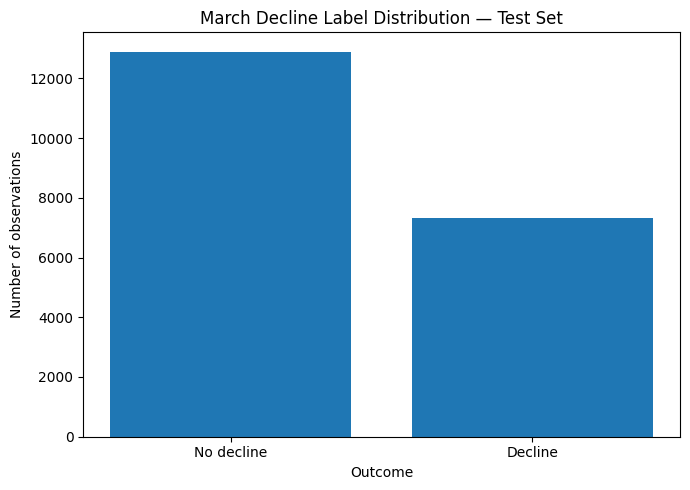

Saved: capstone_artifacts/decline_label_distribution.png


In [54]:
label_counts = (
    y_test
    .value_counts()
    .sort_index()
)

labels = ["No decline", "Decline"]

plt.figure(figsize=(7, 5))

plt.bar(
    labels,
    label_counts.values
)

plt.title("March Decline Label Distribution — Test Set")
plt.xlabel("Outcome")
plt.ylabel("Number of observations")

plt.tight_layout()

plt.savefig(
    f"{ARTIFACT_DIR}/decline_label_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", f"{ARTIFACT_DIR}/decline_label_distribution.png")

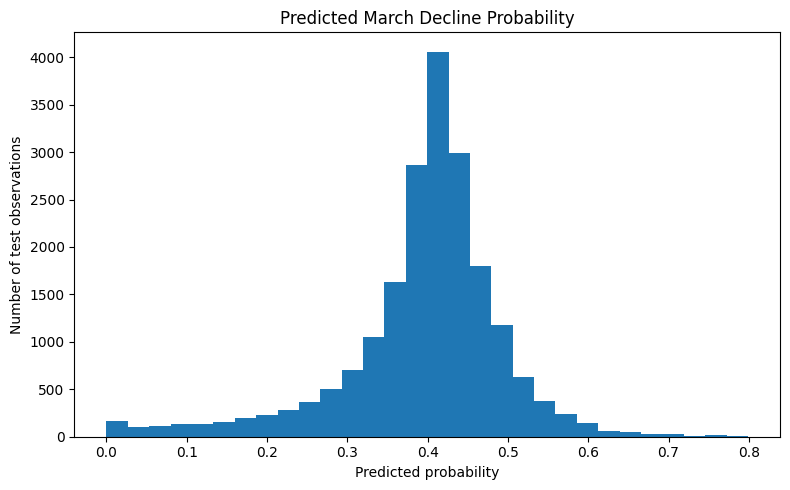

Saved: capstone_artifacts/prediction_probability_distribution.png


In [55]:
plt.figure(figsize=(8, 5))

plt.hist(
    model_probability,
    bins=30
)

plt.title("Predicted March Decline Probability")
plt.xlabel("Predicted probability")
plt.ylabel("Number of test observations")

plt.tight_layout()

plt.savefig(
    f"{ARTIFACT_DIR}/prediction_probability_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    f"{ARTIFACT_DIR}/prediction_probability_distribution.png"
)

In [56]:
coefficient_artifact = coefficients[
    ["feature", "coefficient"]
].copy()

display(
    coefficient_artifact.style.format({
        "coefficient": "{:.4f}"
    })
)

coefficient_artifact.to_csv(
    f"{ARTIFACT_DIR}/logistic_regression_coefficients.csv",
    index=False
)

print(
    "Saved:",
    f"{ARTIFACT_DIR}/logistic_regression_coefficients.csv"
)

,feature,coefficient
0,impressions_30d,-0.5750
2,avg_position,0.1953
3,days_with_impressions,-0.0799
1,clicks_30d,0.0300


Saved: capstone_artifacts/logistic_regression_coefficients.csv


In [58]:
recommendations = model_frame.iloc[test_idx].copy()

recommendations["predicted_decline_probability"] = model_probability

recommendations["priority_rank"] = (
    recommendations["predicted_decline_probability"]
    .rank(
        method="first",
        ascending=False
    )
    .astype(int)
)

recommendations["priority_band"] = pd.cut(
    recommendations["predicted_decline_probability"],
    bins=[-np.inf, 0.25, 0.50, 0.75, np.inf],
    labels=[
        "Lower priority",
        "Monitor",
        "High priority",
        "Highest priority"
    ]
)

ranked_recommendations = (
    recommendations
    .sort_values(
        "predicted_decline_probability",
        ascending=False
    )
)

recommendation_artifact = ranked_recommendations[
    [
        "priority_rank",
        "content_hash_id",
        "predicted_decline_probability",
        "priority_band",
        "impressions_30d",
        "clicks_30d",
        "avg_position",
        "days_with_impressions"
    ]
].head(25).copy()

display(
    recommendation_artifact.style.format({
        "predicted_decline_probability": "{:.4f}",
        "avg_position": "{:.2f}"
    })
)

recommendation_artifact.to_csv(
    f"{ARTIFACT_DIR}/ranked_recommendations_top25.csv",
    index=False
)

print(
    "\nSaved:",
    f"{ARTIFACT_DIR}/ranked_recommendations_top25.csv"
)

print(
    "Top recommendation probability:",
    f"{recommendation_artifact['predicted_decline_probability'].iloc[0]:.4f}"
)

,priority_rank,content_hash_id,predicted_decline_probability,priority_band,impressions_30d,clicks_30d,avg_position,days_with_impressions
33786,1,content_ece02531eb94e7c4,0.7989,Highest priority,112.000000,1.000000,81.12,28
40330,2,content_4b795afb31807b31,0.7984,Highest priority,201.000000,1.000000,77.08,19
12501,3,content_8646695cbbe776fe,0.7815,Highest priority,149.000000,1.000000,76.46,28
12641,4,content_bc20268efe2201b3,0.7690,Highest priority,29.000000,1.000000,61.54,5
7666,5,content_1905fc9fb65c4f9b,0.7635,Highest priority,43.000000,1.000000,64.54,14
33498,6,content_db160c0dff25cb74,0.7629,Highest priority,669.000000,2.000000,73.99,28
39437,7,content_7eba9492a6364144,0.7595,Highest priority,16.000000,1.000000,61.95,11
33679,8,content_718ab3123d9e76d5,0.7562,Highest priority,6.000000,1.000000,58.20,5
38314,9,content_9c06c93716b86a31,0.7562,Highest priority,282.000000,1.000000,70.54,28
5934,10,content_8565de4bef26bf21,0.7556,Highest priority,145.000000,2.000000,68.26,25



Saved: capstone_artifacts/ranked_recommendations_top25.csv
Top recommendation probability: 0.7989


### Artifact interpretation

The artifacts are intended to support inspection rather than imply certainty.

The model-versus-baseline table shows that Logistic Regression provides a modest improvement in ranking performance over the Week-4 baseline.

The label distribution shows that decline is common enough to matter operationally but is not the majority outcome.

The probability distribution shows how the model separates observations into different levels of estimated decline risk.

The coefficient table provides directional interpretation of the four February signals used by the model.

The ranked recommendation table is the operational output: it provides an ordered review queue based on predicted decline probability. These rankings should be treated as decision-support signals and followed by human review.

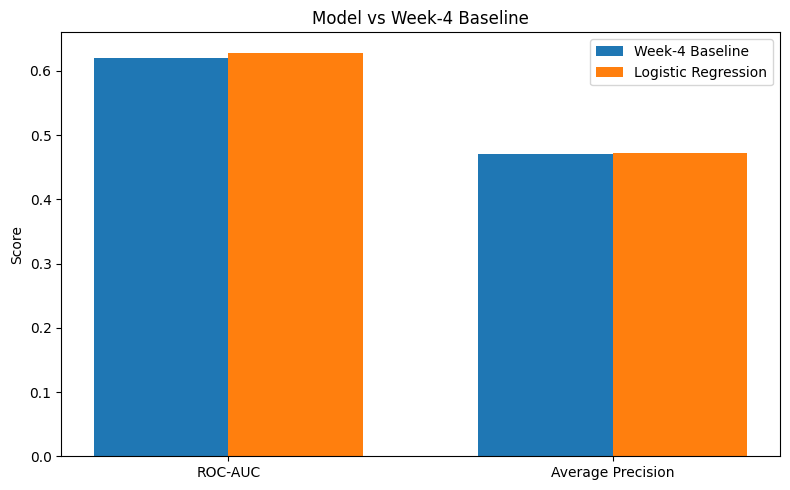

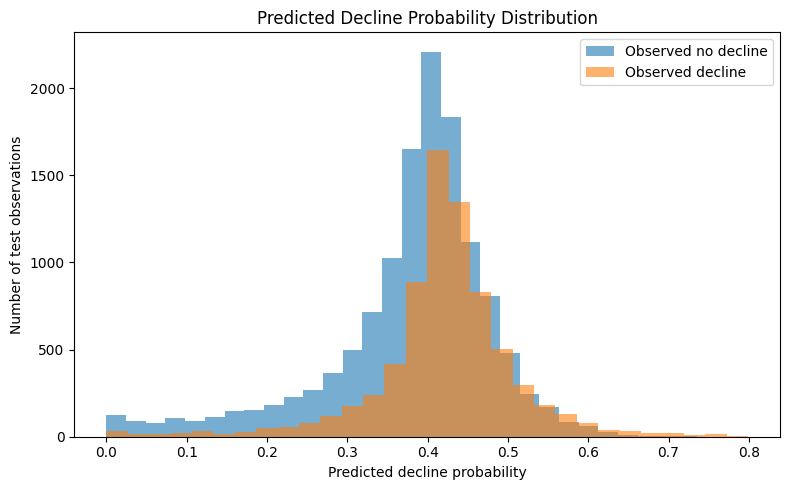

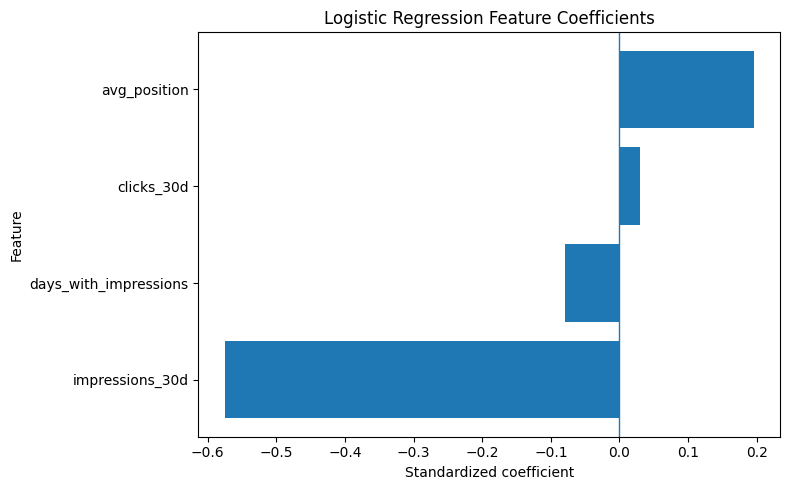

Capstone chart artifacts generated successfully.


In [59]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Artifact 1: Model vs baseline performance
# ---------------------------------------------------------

metrics_plot = pd.DataFrame({
    "metric": ["ROC-AUC", "Average Precision"],
    "baseline": [baseline_auc, baseline_ap],
    "model": [model_auc, model_ap]
})

x = np.arange(len(metrics_plot))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width / 2,
    metrics_plot["baseline"],
    width,
    label="Week-4 Baseline"
)

plt.bar(
    x + width / 2,
    metrics_plot["model"],
    width,
    label="Logistic Regression"
)

plt.xticks(x, metrics_plot["metric"])
plt.ylabel("Score")
plt.title("Model vs Week-4 Baseline")
plt.legend()
plt.tight_layout()

plt.savefig(
    "capstone_artifacts/model_vs_baseline.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# Artifact 2: Prediction probability distribution
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    model_probability[y_test_array == 0],
    bins=30,
    alpha=0.6,
    label="Observed no decline"
)

plt.hist(
    model_probability[y_test_array == 1],
    bins=30,
    alpha=0.6,
    label="Observed decline"
)

plt.xlabel("Predicted decline probability")
plt.ylabel("Number of test observations")
plt.title("Predicted Decline Probability Distribution")
plt.legend()
plt.tight_layout()

plt.savefig(
    "capstone_artifacts/predicted_probability_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# Artifact 3: Logistic Regression coefficients
# ---------------------------------------------------------

coefficient_plot = coefficients.sort_values(
    "coefficient"
)

plt.figure(figsize=(8, 5))

plt.barh(
    coefficient_plot["feature"],
    coefficient_plot["coefficient"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel("Standardized coefficient")
plt.ylabel("Feature")
plt.title("Logistic Regression Feature Coefficients")
plt.tight_layout()

plt.savefig(
    "capstone_artifacts/logistic_coefficients.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


print("Capstone chart artifacts generated successfully.")

In [60]:
import os

artifact_files = []

for root, dirs, files in os.walk("capstone_artifacts"):
    for file in files:
        artifact_files.append(
            os.path.join(root, file)
        )

print("========== CAPSTONE ARTIFACT INVENTORY ==========")

for path in sorted(artifact_files):
    print("-", path)

print("\nTotal artifacts:", len(artifact_files))

========== CAPSTONE ARTIFACT INVENTORY ==========
- capstone_artifacts/decline_label_distribution.png
- capstone_artifacts/logistic_coefficients.png
- capstone_artifacts/logistic_regression_coefficients.csv
- capstone_artifacts/model_vs_baseline.csv
- capstone_artifacts/model_vs_baseline.png
- capstone_artifacts/predicted_probability_distribution.png
- capstone_artifacts/prediction_probability_distribution.png
- capstone_artifacts/ranked_recommendations_top25.csv

Total artifacts: 8


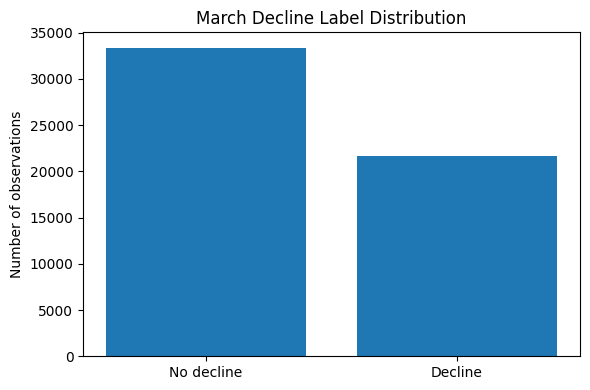

In [48]:
import matplotlib.pyplot as plt

label_counts = (
    model_frame["decline_label"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(6, 4))

plt.bar(
    ["No decline", "Decline"],
    label_counts.values
)

plt.title("March Decline Label Distribution")
plt.ylabel("Number of observations")

plt.tight_layout()
plt.show()

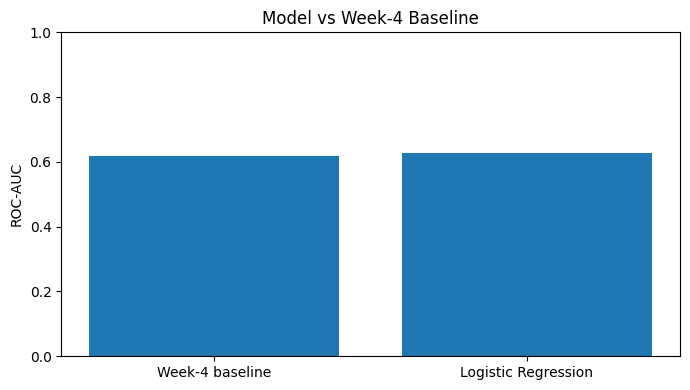

In [49]:
plot_results = pd.DataFrame({
    "Method": [
        "Week-4 baseline",
        "Logistic Regression"
    ],
    "ROC-AUC": [
        baseline_auc,
        model_auc
    ]
})

plt.figure(figsize=(7, 4))

plt.bar(
    plot_results["Method"],
    plot_results["ROC-AUC"]
)

plt.ylim(0, 1)
plt.ylabel("ROC-AUC")
plt.title("Model vs Week-4 Baseline")

plt.tight_layout()
plt.show()

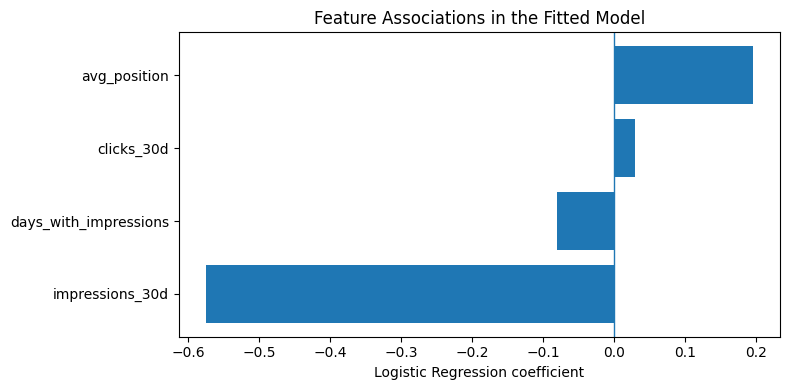

In [50]:
coef_plot = coefficients.sort_values(
    "coefficient"
)

plt.figure(figsize=(8, 4))

plt.barh(
    coef_plot["feature"],
    coef_plot["coefficient"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel("Logistic Regression coefficient")
plt.title("Feature Associations in the Fitted Model")

plt.tight_layout()
plt.show()

In [51]:
error_summary = pd.DataFrame({
    "Metric": [
        "Correct",
        "False positives",
        "False negatives"
    ],
    "Count": [
        (
            (model_prediction == y_test_array)
            .sum()
        ),
        (
            (model_prediction == 1)
            &
            (y_test_array == 0)
        ).sum(),
        (
            (model_prediction == 0)
            &
            (y_test_array == 1)
        ).sum()
    ]
})

display(error_summary)

,Metric,Count
0,Correct,12950
1,False positives,860
2,False negatives,6420


# Abstract

This project evaluates whether February 2026 content-performance signals can help prioritize pages for review when subsequent March performance declines. A binary decline label is defined as March clicks falling by more than 30% relative to February clicks. Four February-only features are used: impressions, clicks, average search position, and days with impressions.

A transparent Week-4 ranking baseline is compared with Logistic Regression using a grouped client-level train/test split. On the held-out test set, Logistic Regression achieves a ROC-AUC of 0.6286 compared with 0.6194 for the baseline, while Average Precision improves from 0.4704 to 0.4721.

The improvement is modest. The result supports using the model as a ranking signal for human content review rather than as an automatic content-refresh decision or causal estimate of refresh impact.

## Reproducibility

The analysis uses a fixed random seed of `42` and a grouped 80/20 train/test split by client.

The modelling decision point is February 28, 2026.

The future outcome window is March 1–31, 2026.

The decline threshold is:

`March clicks < 0.70 × February clicks`

The model features are:

- `impressions_30d`
- `clicks_30d`
- `avg_position`
- `days_with_impressions`

March outcome fields are excluded from the feature matrix.

The model pipeline performs median imputation, standardization, and Logistic Regression.

The evaluation compares the model with the Week-4 baseline on the same held-out observations.

## Conclusion

The analysis shows that a simple Logistic Regression model provides a small but measurable improvement over the Week-4 transparent baseline for ranking observations associated with subsequent March decline.

The ROC-AUC improvement is `+0.0092`, while the Average Precision improvement is `+0.0017`.

The result is therefore best described as a modest directional improvement rather than a major predictive breakthrough.

The practical value of the work is the conversion of observed February performance signals into a reproducible ranked review queue. The final decision remains with the content or SEO team.

## Acknowledgments & data credit

This project was completed using the FlyRank internship warehouse and the associated internship analysis environment.

Data and project context are credited to **FlyRank AI**.

[FlyRank AI](https://flyrank.ai)

# ML-12 — 5-Minute Demo Outline

## 0:00–0:45 — Problem

The goal is to help an SEO/content team decide which pages deserve review first when their performance may be declining.

The prediction point is the end of February 2026.

## 0:45–1:30 — Data and label

February data provides the model features.

March is held out as the future outcome.

A page is labelled as a decline when March clicks fall by more than 30% relative to February clicks.

## 1:30–2:30 — Method

I use four February-only features:

- impressions
- clicks
- average position
- days with impressions

I compare Logistic Regression with the transparent Week-4 baseline.

The train/test split is grouped by client to prevent client overlap between training and test.

## 2:30–3:30 — Results

The Week-4 baseline achieves:

- ROC-AUC: 0.6194
- Average Precision: 0.4704

Logistic Regression achieves:

- ROC-AUC: 0.6286
- Average Precision: 0.4721

The improvement is +0.0092 ROC-AUC and +0.0017 Average Precision.

## 3:30–4:15 — What the model learned

The strongest fitted coefficient by absolute value is impressions_30d.

Average position is the next strongest signal.

These are associations observed in this dataset, not causal effects.

## 4:15–5:00 — Decision output and limitations

The model is used to rank pages for human review.

It does not automatically recommend refreshing content.

The main limitation is that the model observes one February-to-March transition and uses only a small feature set.

The correct interpretation is therefore decision support and prioritization, not causal prediction of refresh impact.

# ML-12 — Social Post Cut

I built a content-performance decline model as part of my FlyRank AI internship work.

The question was simple: can February performance signals help rank pages that are more likely to experience a meaningful decline in March?

I compared a transparent Week-4 baseline with Logistic Regression using four February-only features: impressions, clicks, average position, and days with impressions.

On a client-grouped held-out test set:

- Baseline ROC-AUC: 0.6194
- Logistic Regression ROC-AUC: 0.6286
- Improvement: +0.0092

Average Precision improved from 0.4704 to 0.4721.

The improvement is modest, which is exactly why I would frame this as a decision-support and ranking system rather than a "highly accurate predictor."

The useful output is a ranked review queue that helps a content team decide where to investigate first.

The model does not prove that refreshing a page will improve performance. It only identifies observed signals associated with subsequent decline.

# ML-12 — Employer-Facing Summary

I built and evaluated a Logistic Regression model to prioritize content pages for review based on the likelihood of a subsequent performance decline. The model uses only February 2026 signals, uses a client-grouped train/test split to reduce leakage risk, and improves ROC-AUC from 0.6194 for the Week-4 baseline to 0.6286. The final output is a ranked decision-support queue rather than an automated content-refresh recommendation, with explicit leakage checks, error analysis, limitations, and reproducible evaluation.

In [52]:
print("========== CAPSTONE SANITY CHECK ==========")

print(f"Modeling rows: {len(model_frame):,}")
print(f"Training rows: {len(X_train):,}")
print(f"Test rows:     {len(X_test):,}")

print(f"\nDecline base rate: {y_test.mean():.4f}")

print("\nMODEL VS BASELINE")
print(f"Baseline ROC-AUC: {baseline_auc:.4f}")
print(f"Model ROC-AUC:    {model_auc:.4f}")
print(f"AUC improvement:  {model_auc - baseline_auc:+.4f}")

print(f"\nBaseline AP:      {baseline_ap:.4f}")
print(f"Model AP:         {model_ap:.4f}")
print(f"AP improvement:   {model_ap - baseline_ap:+.4f}")

print("\nLEAKAGE CHECK")

for feature in FEATURES:
    print(" -", feature)

for forbidden in [
    "march_clicks",
    "feb_clicks",
    "decline_label"
]:
    assert forbidden not in FEATURES

assert len(overlap) == 0

print("\nNo future/label-derived fields used as model features.")
print("Client overlap:", len(overlap))

print("\nW5 methodology carried into Capstone: PASSED")

print("\n========== CAPSTONE SANITY CHECK: PASSED ==========")

========== CAPSTONE SANITY CHECK ==========
Modeling rows: 55,090
Training rows: 34,860
Test rows:     20,230

Decline base rate: 0.3625

MODEL VS BASELINE
Baseline ROC-AUC: 0.6194
Model ROC-AUC:    0.6286
AUC improvement:  +0.0092

Baseline AP:      0.4704
Model AP:         0.4721
AP improvement:   +0.0017

LEAKAGE CHECK
 - impressions_30d
 - clicks_30d
 - avg_position
 - days_with_impressions

No future/label-derived fields used as model features.
Client overlap: 0

W5 methodology carried into Capstone: PASSED

========== CAPSTONE SANITY CHECK: PASSED ==========


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
